In [1]:
# ¿Cómo podemos estimar, con fines educativos, la probabilidad de que un caso histórico corresponda a la clase M a partir de mediciones numéricas?

# Estas mediciones históricas permiten estudiar clasificación; el resultado no es un diagnóstico ni debe usarse para decisiones clínicas.

from pathlib import Path
import os

import pandas as pd

DATA_PATH = Path("../data/wisc_bc_data.csv")
SUBMISSION_PATH = Path("../submission")
assert DATA_PATH.is_file(), f"No se encontró el archivo de datos: {DATA_PATH}"
assert DATA_PATH.stat().st_size > 0, f"El archivo de datos está vacío: {DATA_PATH}"
assert SUBMISSION_PATH.is_dir(), f"No se encontró el directorio de artefactos: {SUBMISSION_PATH}"
assert os.access(SUBMISSION_PATH, os.W_OK), f"No hay permiso de escritura en: {SUBMISSION_PATH}"

dataframe = pd.read_csv(DATA_PATH)
dataframe.shape

(569, 32)

In [2]:
# ¿Cuál es la clase que requiere priorización y cuántos casos representa?

target = (dataframe["diagnosis"] == "M").astype(int)
target.value_counts(normalize=True)

diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64

In [3]:
# Se conservan dos mediciones para hacer visible la especificación del modelo.

base_features = ["texture_mean", "compactness_mean"]
X_base = dataframe[base_features].copy()
X_base.describe()

,texture_mean,compactness_mean
count,569.000000,569.000000
mean,19.289649,0.104341
std,4.301036,0.052813
min,9.710000,0.019380
25%,16.170000,0.064920
50%,18.840000,0.092630
75%,21.800000,0.130400
max,39.280000,0.345400


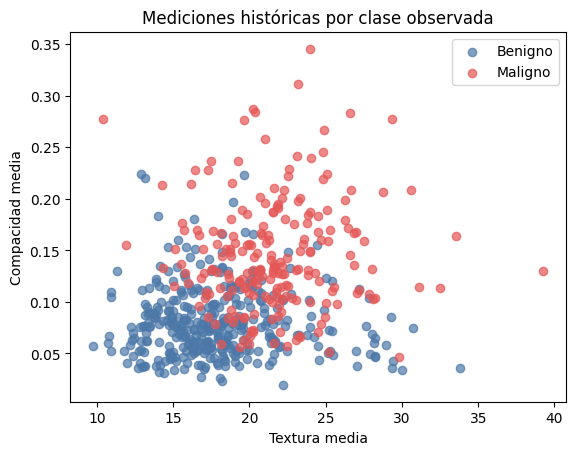

In [4]:
# La dispersión permite observar las mediciones disponibles antes de atribuir capacidad predictiva al modelo.

import matplotlib.pyplot as plt

for diagnosis, color, label in [("B", "#4c78a8", "Benigno"), ("M", "#e45756", "Maligno")]:
    cases = dataframe[dataframe["diagnosis"] == diagnosis]
    plt.scatter(
        cases["texture_mean"],
        cases["compactness_mean"],
        color=color,
        label=label,
        alpha=0.7,
    )

plt.xlabel("Textura media")
plt.ylabel("Compacidad media")
plt.title("Mediciones históricas por clase observada")
plt.legend()
plt.show()

In [5]:
# Se reserva una muestra estratificada que no participa en el ajuste.

from sklearn.model_selection import train_test_split

train_index, test_index = train_test_split(
    dataframe.index,
    train_size=0.8,
    random_state=0,
    stratify=target,
)
len(train_index), len(test_index)

(455, 114)

In [6]:
# Se ajusta una logística base y se expresa el resultado como probabilidad.

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

base_estimator = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=0)),
    ]
)
base_estimator.fit(X_base.loc[train_index], target.loc[train_index])
base_probability = base_estimator.predict_proba(X_base.loc[test_index])[:, 1]
base_probability[:10]

array([0.03116646, 0.78649177, 0.93341107, 0.05880998, 0.18879069,
       0.56651001, 0.07609932, 0.87013704, 0.62790879, 0.41657436])

In [7]:
# ¿Cambia el riesgo cuando la textura crece en combinación con la compactación?

X_flexible = X_base.copy()
X_flexible["texture_mean_squared"] = X_flexible["texture_mean"] ** 2
X_flexible["texture_mean_x_compactness_mean"] = (
    X_flexible["texture_mean"] * X_flexible["compactness_mean"]
)
X_flexible.head()

,texture_mean,compactness_mean,texture_mean_squared,texture_mean_x_compactness_mean
0,10.38,0.27760,107.7444,2.881488
1,17.77,0.07864,315.7729,1.397433
2,21.25,0.15990,451.5625,3.397875
3,20.38,0.28390,415.3444,5.785882
4,14.34,0.13280,205.6356,1.904352


In [8]:
# Se ajusta una logística cuya frontera sigue siendo lineal en los términos construidos.

flexible_estimator = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=0)),
    ]
)
flexible_estimator.fit(X_flexible.loc[train_index], target.loc[train_index])
flexible_probability = flexible_estimator.predict_proba(
    X_flexible.loc[test_index]
)[:, 1]
flexible_probability[:10]

array([0.03489566, 0.83106958, 0.95880308, 0.05127665, 0.17338897,
       0.60917394, 0.07779101, 0.90503725, 0.56286267, 0.43882329])

In [9]:
# ¿Cuál especificación ordena mejor los casos reservados sin confundir probabilidad con diagnóstico?

from sklearn.metrics import accuracy_score, roc_auc_score

model_comparison = pd.DataFrame(
    [
        {
            "model": "logística base",
            "test_auc": roc_auc_score(
                target.loc[test_index],
                base_estimator.predict_proba(X_base.loc[test_index])[:, 1],
            ),
            "test_accuracy": accuracy_score(
                target.loc[test_index],
                base_estimator.predict(X_base.loc[test_index]),
            ),
        },
        {
            "model": "logística flexible",
            "test_auc": roc_auc_score(
                target.loc[test_index],
                flexible_estimator.predict_proba(X_flexible.loc[test_index])[:, 1],
            ),
            "test_accuracy": accuracy_score(
                target.loc[test_index],
                flexible_estimator.predict(X_flexible.loc[test_index]),
            ),
        },
    ]
).round(3)

model_comparison

,model,test_auc,test_accuracy
0,logística base,0.842,0.754
1,logística flexible,0.852,0.746


In [10]:
# ¿La diferencia entre especificaciones supera la variación que introduce la muestra de prueba, o podría ser ruido?

import numpy as np

rng = np.random.default_rng(0)
n_target_resamples = 2000
test_positions = np.arange(len(test_index))
y_test = target.loc[test_index].to_numpy()
base_pred = base_estimator.predict(X_base.loc[test_index])
flexible_pred = flexible_estimator.predict(X_flexible.loc[test_index])

auc_differences = []
accuracy_differences = []
for _ in range(n_target_resamples):
    sample_positions = rng.choice(test_positions, size=len(test_positions), replace=True)
    y_sample = y_test[sample_positions]
    if y_sample.min() == y_sample.max():
        continue
    auc_differences.append(
        roc_auc_score(y_sample, flexible_probability[sample_positions])
        - roc_auc_score(y_sample, base_probability[sample_positions])
    )
    accuracy_differences.append(
        accuracy_score(y_sample, flexible_pred[sample_positions])
        - accuracy_score(y_sample, base_pred[sample_positions])
    )

auc_differences = np.array(auc_differences)
accuracy_differences = np.array(accuracy_differences)

difference_bootstrap = pd.DataFrame(
    [
        {
            "metric": "auc",
            "observed_difference": roc_auc_score(y_test, flexible_probability)
            - roc_auc_score(y_test, base_probability),
            "ci_low": np.percentile(auc_differences, 2.5),
            "ci_high": np.percentile(auc_differences, 97.5),
            "n_resamples": len(auc_differences),
        },
        {
            "metric": "accuracy",
            "observed_difference": accuracy_score(y_test, flexible_pred)
            - accuracy_score(y_test, base_pred),
            "ci_low": np.percentile(accuracy_differences, 2.5),
            "ci_high": np.percentile(accuracy_differences, 97.5),
            "n_resamples": len(accuracy_differences),
        },
    ]
)

difference_bootstrap.round(4)

,metric,observed_difference,ci_low,ci_high,n_resamples
0,auc,0.0103,-0.0010,0.0239,2000
1,accuracy,-0.0088,-0.0263,0.0000,2000


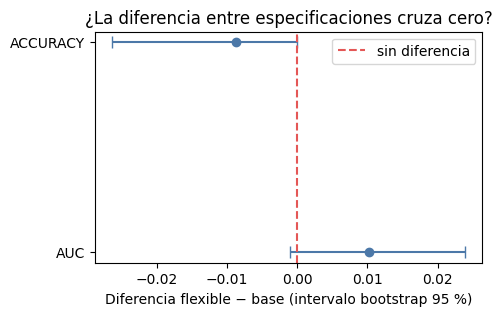

In [11]:
# La gráfica hace visible si cada intervalo cruza cero antes de interpretar el resultado en texto.

fig, ax = plt.subplots(figsize=(5, 3))
y_positions = np.arange(len(difference_bootstrap))
lower_error = difference_bootstrap["observed_difference"] - difference_bootstrap["ci_low"]
upper_error = difference_bootstrap["ci_high"] - difference_bootstrap["observed_difference"]

ax.errorbar(
    difference_bootstrap["observed_difference"],
    y_positions,
    xerr=[lower_error, upper_error],
    fmt="o",
    color="#4c78a8",
    capsize=4,
)
ax.axvline(0, color="#e45756", linestyle="--", label="sin diferencia")
ax.set_yticks(y_positions)
ax.set_yticklabels(difference_bootstrap["metric"].str.upper())
ax.set_xlabel("Diferencia flexible − base (intervalo bootstrap 95 %)")
ax.set_title("¿La diferencia entre especificaciones cruza cero?")
ax.legend()
plt.show()

# Los dos intervalos del 95 % incluyen cero: AUC va de -0.001 a 0.024 y exactitud de -0.026 a 0.000.
# Ninguna de las dos diferencias observadas (AUC +0.010, exactitud -0.009) es distinguible del ruido
# de muestreo en esta partición de prueba. La lectura de H04 se mantiene como contraste entre
# ordenamiento y decisión por umbral, pero no como evidencia de que la especificación flexible
# mejora el ordenamiento: con esta muestra de prueba no puede descartarse que la diferencia sea cero.
# Este intervalo sólo captura la variación que introduce la muestra de prueba; no dice nada sobre la
# variación de la partición entrenamiento/prueba ni sobre la incertidumbre del ajuste de los coeficientes.

In [12]:
# Se conserva el intervalo bootstrap para que la lectura de H04 pueda revisarse junto con la comparación puntual.

from pathlib import Path

submission_dir = Path("../submission")
difference_bootstrap.to_csv(submission_dir / "difference_bootstrap.csv", index=False)

In [13]:
# Se conservan los modelos, la comparación y sus metadatos para verificación posterior.

import json
import pickle
from pathlib import Path

submission_dir = Path("../submission")
model_comparison.to_csv(submission_dir / "model_comparison.csv", index=False)

with (submission_dir / "base_estimator.pkl").open("wb") as file:
    pickle.dump(base_estimator, file)

with (submission_dir / "flexible_estimator.pkl").open("wb") as file:
    pickle.dump(flexible_estimator, file)

metrics = {
    "test_size": len(test_index),
    "positive_class": "M",
    "base_features": base_features,
    "flexible_features": list(X_flexible.columns),
    "test_auc": model_comparison.set_index("model")["test_auc"].to_dict(),
}

with (submission_dir / "metrics.json").open("w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)